# Importing Required Libraries

This cell imports all the important Python libraries required for Polynomial Regression.

- `pandas` → used for data handling
- `numpy` → used for numerical operations
- `seaborn` and `matplotlib` → used for data visualization
- `%matplotlib inline` → displays plots inside the notebook

In [1]:
# Importing required library
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Creating Non-Linear Dataset

This cell creates a quadratic dataset using the equation:

`y = 0.5x² + 1.5x + 2 + noise`

Random noise is added using `np.random.randn()` to make the dataset realistic. The scatter plot helps visualize the non-linear relationship between X and y.

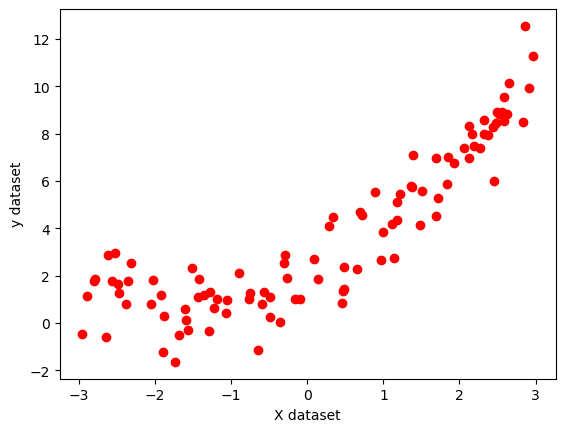

In [2]:
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100 , 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
# Plotting graph
plt.scatter(X,y,color='r')
plt.xlabel('X dataset')
plt.ylabel('y dataset')
plt.show()

### Output Explanation

The output shows a scatter plot of the generated quadratic dataset. The curved pattern confirms that the relationship between X and y is non-linear.

# Splitting Dataset into Training and Testing Sets

This cell divides the dataset into training data and testing data.

- `X_train`, `y_train` → used to train the model
- `X_test`, `y_test` → used to evaluate the model
- `test_size=0.25` means 25% data is reserved for testing

In [3]:
# Splitting dataset into training and testing data
from sklearn.model_selection import train_test_split
# Splitting dataset into training and testing data
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.25, random_state=42)

# Importing StandardScaler

This cell imports and creates the `StandardScaler` object.

Feature scaling standardizes the dataset so that all values have similar scale. This improves model performance and stability.

In [4]:
# Creating StandardScaler object
from sklearn.preprocessing import StandardScaler
# Creating StandardScaler object
scaler = StandardScaler()

# Scaling the Dataset

This cell applies feature scaling on training and testing data.

- `fit_transform()` learns scaling parameters and transforms training data
- `transform()` applies the same scaling on test data

In [5]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating Linear Regression Model

This cell creates a Linear Regression model.

Initially, a simple linear regression model is applied to check whether a straight line can fit the quadratic dataset properly.

In [6]:
# Implementing linear Regression model to check best fit line 
from sklearn.linear_model import LinearRegression
reg_1 = LinearRegression(n_jobs=-1)

# Training Linear Regression Model

This cell trains the Linear Regression model using scaled training data.

The model learns the relationship between input features and target values.

In [7]:
# Training/Fitting the model
reg_1.fit(X_train_scaled, y_train)

LinearRegression(n_jobs=-1)

### Output Explanation

The output confirms that the Linear Regression model has been successfully trained.

# Making Predictions Using Linear Regression

This cell predicts output values for the testing dataset using the trained linear regression model.

In [8]:
# Predicting output values
y_pred = reg_1.predict(X_test_scaled)

# Calculating R² Score for Linear Regression

This cell calculates the R² score.

R² score measures how well the model fits the data.
- Value close to 1 → good model
- Value close to 0 → poor model

In [9]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.6396736905006899


### Output Explanation

The output displays the R² score of the Linear Regression model. A lower score indicates that a straight line cannot properly fit the curved dataset.

# Visualizing Linear Regression Best Fit Line

This cell visualizes the best-fit straight line generated by Linear Regression.

Since the dataset is quadratic, the straight line cannot perfectly fit the data points.

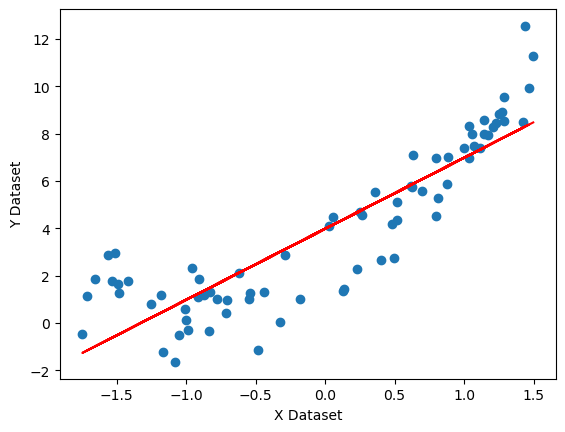

In [10]:
# Lets visualize this model
# Predicting output values
plt.plot(X_train_scaled,reg_1.predict(X_train_scaled),color = 'r')
# Plotting graph
plt.scatter(X_train_scaled,y_train)
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')
plt.show()

### Output Explanation

The graph shows the best-fit straight line. The line does not follow the curved pattern of the data properly.

# Applying Polynomial Feature Transformation

This cell converts normal features into polynomial features of degree 2.

For example:
`x → [1, x, x²]`

This helps Linear Regression model learn non-linear relationships.

In [11]:
# Lets apply polynomial transformation
# Creating polynomial feature transformer
from sklearn.preprocessing import PolynomialFeatures
# Creating polynomial feature transformer
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_Poly = poly.fit_transform(X_train)
X_test_Poly = poly.transform(X_test)

# Viewing Polynomial Features

This cell displays the transformed polynomial features.

Each row now contains:
- Bias term (1)
- x value
- x² value

In [12]:
X_train_Poly

array([[ 1.00000000e+00, -6.48256404e-01,  4.20236365e-01],
       [ 1.00000000e+00, -2.56788239e+00,  6.59401995e+00],
       [ 1.00000000e+00,  2.58256746e+00,  6.66965470e+00],
       [ 1.00000000e+00,  2.83166670e+00,  8.01833630e+00],
       [ 1.00000000e+00, -2.89474188e-01,  8.37953054e-02],
       [ 1.00000000e+00,  2.37470175e+00,  5.63920838e+00],
       [ 1.00000000e+00, -1.36119616e+00,  1.85285498e+00],
       [ 1.00000000e+00,  1.69476084e+00,  2.87221430e+00],
       [ 1.00000000e+00, -2.95656893e+00,  8.74129985e+00],
       [ 1.00000000e+00,  2.55748646e+00,  6.54073700e+00],
       [ 1.00000000e+00,  1.18242670e+00,  1.39813291e+00],
       [ 1.00000000e+00,  2.91111640e+00,  8.47459869e+00],
       [ 1.00000000e+00, -1.19299356e+00,  1.42323363e+00],
       [ 1.00000000e+00,  2.52267978e+00,  6.36391328e+00],
       [ 1.00000000e+00,  2.88403896e-01,  8.31768069e-02],
       [ 1.00000000e+00,  2.18657559e+00,  4.78111281e+00],
       [ 1.00000000e+00, -1.59739260e+00

### Output Explanation

The output displays transformed polynomial features including x and x² terms.

# Training Polynomial Regression Model (Degree 2)

This cell trains Linear Regression on polynomial features and calculates the R² score.

Polynomial Regression usually gives better accuracy for curved datasets.

In [13]:
from sklearn.metrics import r2_score
regression = LinearRegression()
# Training/Fitting the model
regression.fit(X_train_Poly, y_train)
# Predicting output values
y_pred1 = regression.predict(X_test_Poly)
score = r2_score(y_test,y_pred1)
print(score)

0.8820039816555143


### Output Explanation

The output displays the R² score for Polynomial Regression. The score is usually much better than simple linear regression.

# Viewing Model Coefficients

This cell displays the coefficients learned by the Polynomial Regression model.

These coefficients represent the weights of polynomial terms.

In [14]:
print(regression.coef_)

[[0.         1.55309021 0.47747151]]


### Output Explanation

The output shows the coefficients learned by the Polynomial Regression model.

# Viewing Model Intercept

This cell prints the intercept value of the Polynomial Regression model.

Intercept represents the value of y when x = 0.

In [15]:
print(regression.intercept_)

[1.99414188]


### Output Explanation

The output displays the intercept value of the trained model.

# Visualizing Polynomial Regression Predictions

This cell plots actual training points and predicted values.

The polynomial model fits the curved dataset much better compared to simple linear regression.

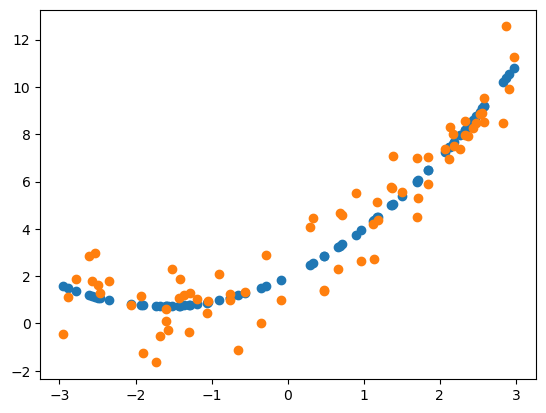

In [16]:
# Predicting output values
plt.scatter(X_train,regression.predict(X_train_Poly))
# Plotting graph
plt.scatter(X_train , y_train)
plt.show()

### Output Explanation

The graph shows that Polynomial Regression fits the curved data much more accurately.

# Creating Polynomial Features of Degree 3

This cell creates polynomial features up to degree 3.

Now the transformed data contains:
`[1, x, x², x³]`

In [17]:
# Creating polynomial feature transformer
poly = PolynomialFeatures(degree=3,include_bias=True)
X_train_Poly = poly.fit_transform(X_train)
X_test_Poly = poly.transform(X_test)

# Training Polynomial Regression Model (Degree 3)

This cell trains the degree-3 Polynomial Regression model and evaluates its performance using R² score.

In [18]:
from sklearn.metrics import r2_score
regression = LinearRegression()
# Training/Fitting the model
regression.fit(X_train_Poly, y_train)
# Predicting output values
y_pred1 = regression.predict(X_test_Poly)
score = r2_score(y_test,y_pred1)
print(score)

0.8798364831479087


### Output Explanation

The output displays the R² score for degree-3 Polynomial Regression.

# Creating New Data for Smooth Curve Prediction

This cell generates new evenly spaced data points between -3 and 3.

These points are transformed into polynomial features to create a smooth prediction curve.

In [19]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

### Output Explanation

The output displays newly generated polynomial feature values for smooth predictions.

# Plotting Final Polynomial Regression Curve

This cell visualizes the final prediction curve along with training and testing points.

The red curve represents the polynomial regression predictions.

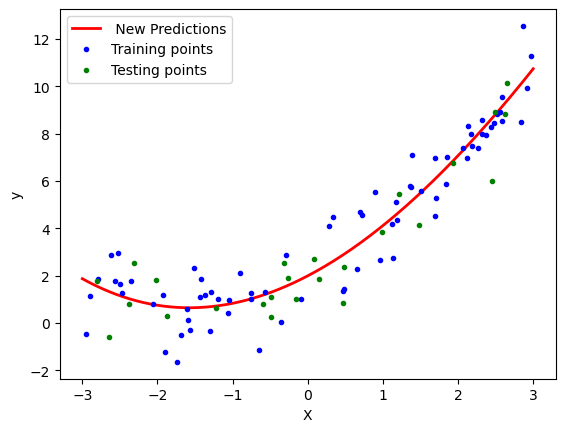

In [20]:
# Predicting output values
y_new = regression.predict(X_new_poly)
# Plotting graph
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
# Plotting graph
plt.plot(X_train, y_train, "b.",label='Training points')
# Plotting graph
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Output Explanation

The graph displays the smooth polynomial regression curve along with training and testing points.

## Pipeline Concepts ##

# Importing Pipeline

This cell imports `Pipeline` from sklearn.

Pipeline helps combine preprocessing steps and model training into a single workflow.

In [21]:
# Creating pipeline
from sklearn.pipeline import Pipeline

# Creating Reusable Polynomial Regression Function

This cell defines a reusable function named `poly_regression()`.

The function:
- Creates polynomial features
- Trains the model
- Predicts new values
- Plots the regression curve

In [22]:
# Function to perform Polynomial Regression and plot the results
def poly_regression(degree):


    # Creating 200 evenly spaced values between -3 and 3
    # reshape(200,1) converts the data into 2D format required by sklearn
    X_new = np.linspace(-3,3,200).reshape(200,1)


    # Creating polynomial features object
    # degree=degree → creates polynomial terms up to given degree
    # include_bias=True → adds column of 1s (intercept term)
# Creating polynomial feature transformer
    poly_features = PolynomialFeatures(degree=degree , include_bias=True)


    # Creating Linear Regression model object
    # Linear regression is used after polynomial transformation
    lin_reg = LinearRegression()


    # Creating a pipeline
# Creating pipeline
    # Pipeline performs multiple steps sequentially:
    # 1. Convert normal features into polynomial features
    # 2. Apply linear regression on transformed data
# Creating pipeline
    poly_regression = Pipeline([


        # Step 1: Polynomial feature transformation
        ('poly_features', poly_features),


        # Step 2: Linear regression model
        ('lin_reg', lin_reg)
    ])


    # Training the model using training data
    # X_train → input features
    # y_train → target/output values
    # Internally:
    # - polynomial features are generated
    # - linear regression model is fitted
# Training/Fitting the model
    poly_regression.fit(X_train , y_train)


    # Predicting output values for newly generated X values
    # This helps create a smooth curve for plotting
# Predicting output values
    y_pred_new = poly_regression.predict(X_new)


    # Plotting prediction curve
    # X_new → x-axis values
    # y_pred_new → predicted y values
    # 'r' means red color
    # linewidth=2 controls thickness of curve
# Plotting graph
    plt.plot(X_new, y_pred_new, 'r',
             label="Degree " + str(degree),
             linewidth=2)


    # Plotting training data points
    # "b." means blue colored points
# Plotting graph
    plt.plot(X_train, y_train, "b.", linewidth=3)


    # Plotting testing data points
    # "g." means green colored points
# Plotting graph
    plt.plot(X_test, y_test, "g.", linewidth=3)


    # Showing legend on graph
    # upper left → legend position
    plt.legend(loc="upper left")


    # Label for x-axis
    plt.xlabel("X")


    # Label for y-axis
    plt.ylabel("y")


    # Setting graph axis range
    # x-axis range = -4 to 4
    # y-axis range = 0 to 10
    plt.axis([-4,4,0,10])


    # Displaying the final graph
    plt.show()

# Running Polynomial Regression Function

This cell calls the `poly_regression(6)` function.

It trains a Polynomial Regression model with degree 6 and visualizes the prediction curve.

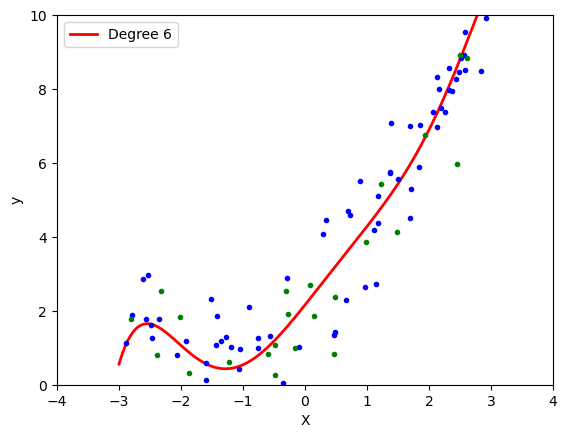

In [23]:
poly_regression(6)

### Output Explanation

The output graph visualizes the Polynomial Regression model with degree 6.

# Code Cell 25

This cell performs an important operation in Polynomial Regression.